In [2]:
from sionna.rt import load_scene, RadioMapSolver
from pathlib import Path
import sys


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "scripts" / "run.py").is_file():
            return p
    raise RuntimeError(
        "Cannot find scripts/run.py. "
        "Use working directory CSIGen (repo root) or a folder inside it."
    )


# Imports from repo (needs CSIGen root on sys.path)
REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array

In [3]:
# base station height
BS_HEIGHT_OFFSET = 30

# 1) Path gain maps and SINR maps are largely different due to interference between multi TX's

In [4]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=4,
                    num_cols=4,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=6,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

Antenna Array Configuration Set:
  - Array: 4x4 (32 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [30.6]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 60.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_4 at position [[0, 0, 30]], azimuth 180.0°
Added BS_0_sector_5 at position [[0, 0, 30]], azimuth 240.0°
Added BS_0_sector_6 at position [[0, 0, 30]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


## **Note:** 

- For radio map solver, receive antenna array params are assumed fixed and modifying them does not matter. See below from the Sionna RT technical report:
```
The receive antenna pattern is not applied here. Instead, the squared norm of the electric field is used. This is equivalent to assuming that a receiver positioned on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
```

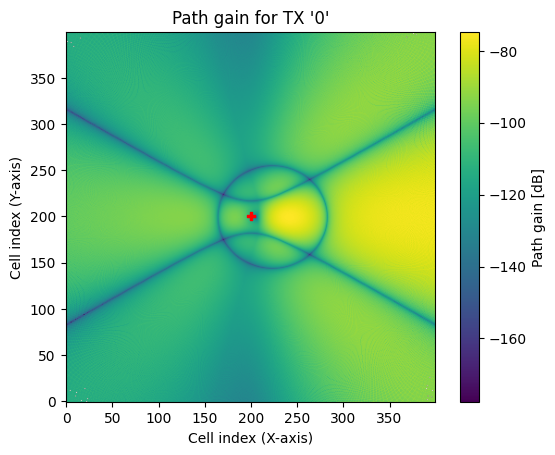

In [5]:
rm.show(metric="path_gain", tx=0);

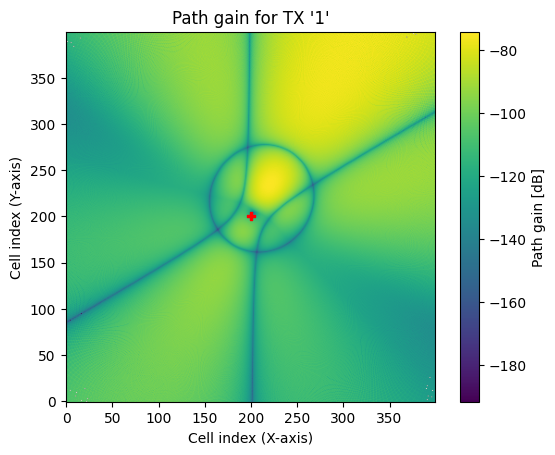

In [6]:
rm.show(metric="path_gain", tx=1);

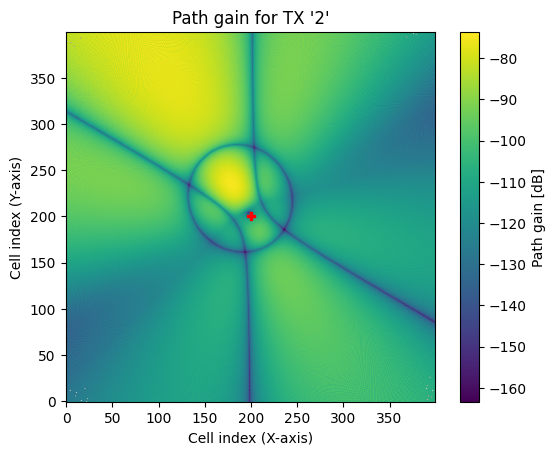

In [7]:
rm.show(metric="path_gain", tx=2);

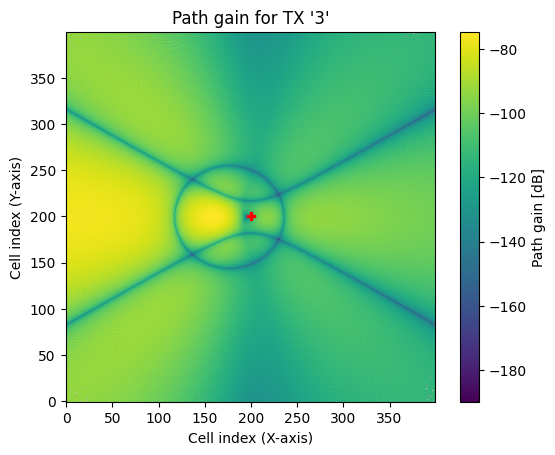

In [8]:
rm.show(metric="path_gain", tx=3);

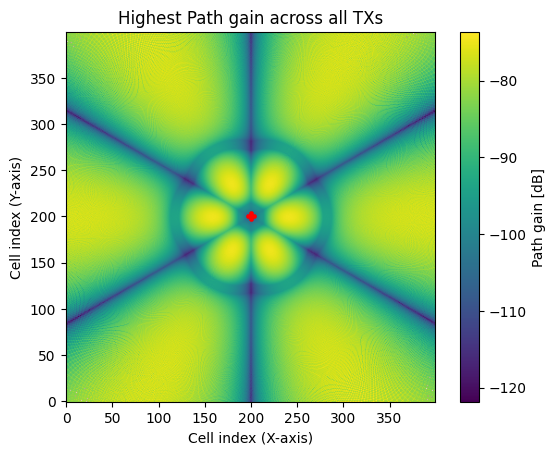

In [9]:
rm.show(metric="path_gain");

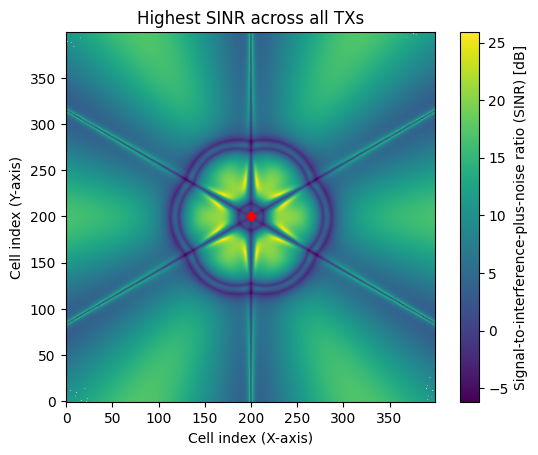

In [10]:
rm.show(metric="sinr");

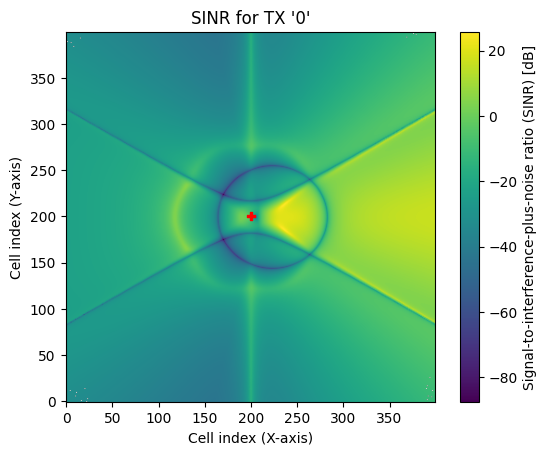

In [11]:
rm.show(metric="sinr", tx=0);

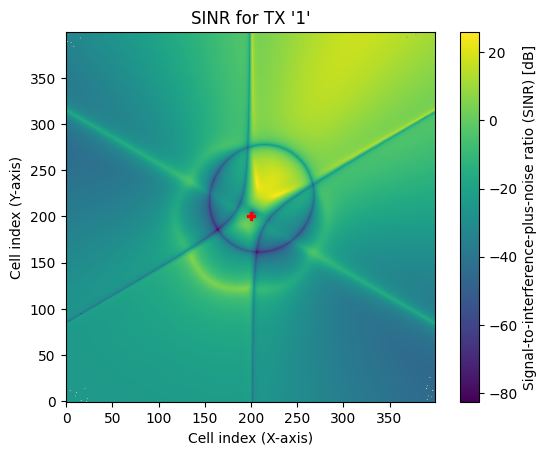

In [12]:
rm.show(metric="sinr", tx=1);

# 2) Visualize the same with 16x1 TX with 6 sectors

In [13]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=16,
                    num_cols=1,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=6,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

Antenna Array Configuration Set:
  - Array: 16x1 (32 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [122.4]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 60.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_4 at position [[0, 0, 30]], azimuth 180.0°
Added BS_0_sector_5 at position [[0, 0, 30]], azimuth 240.0°
Added BS_0_sector_6 at position [[0, 0, 30]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


In [14]:
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

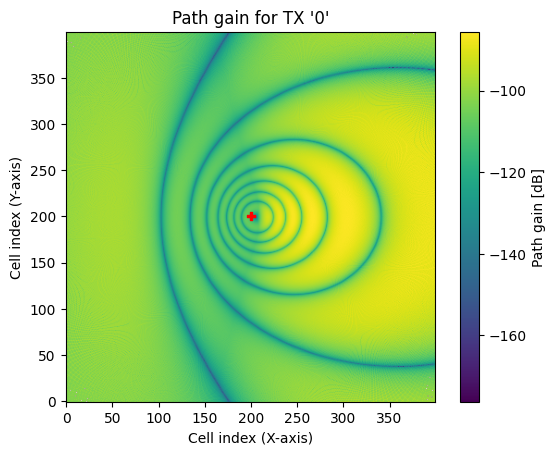

In [15]:
rm.show(metric="path_gain", tx=0);

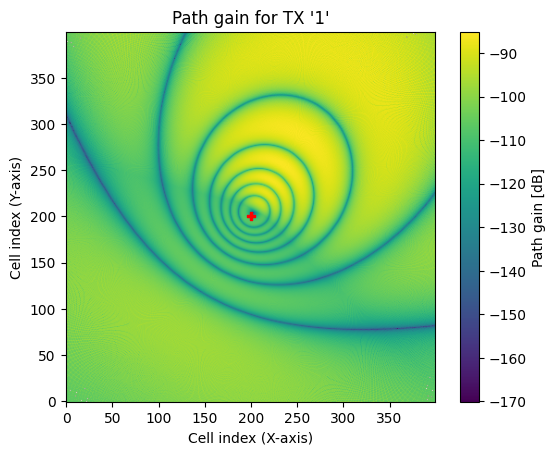

In [16]:
rm.show(metric="path_gain", tx=1);

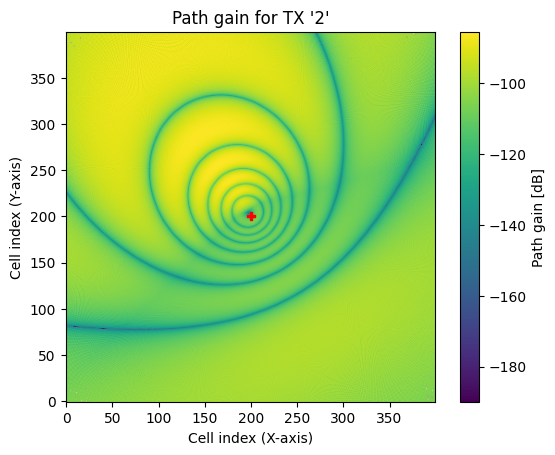

In [17]:
rm.show(metric="path_gain", tx=2);

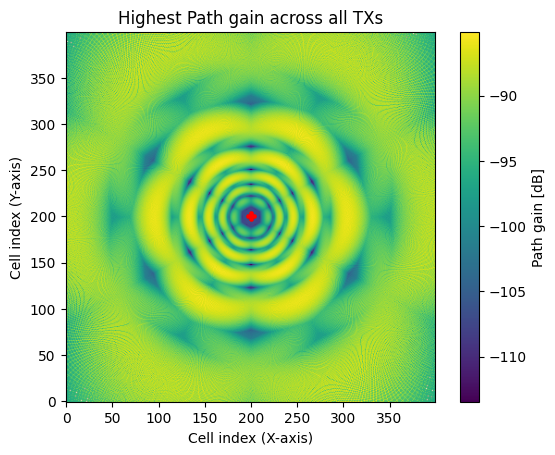

In [18]:
rm.show(metric="path_gain");

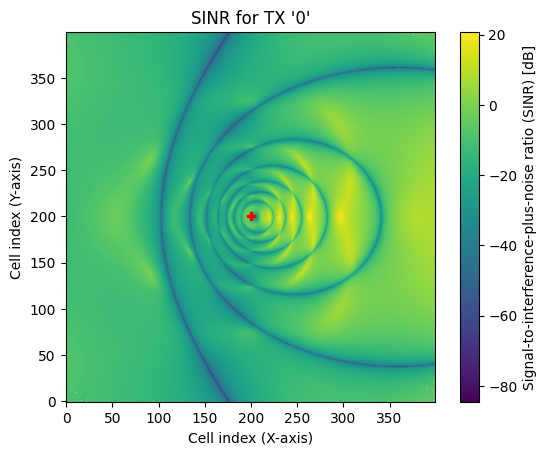

In [19]:
rm.show(metric="sinr", tx=0);

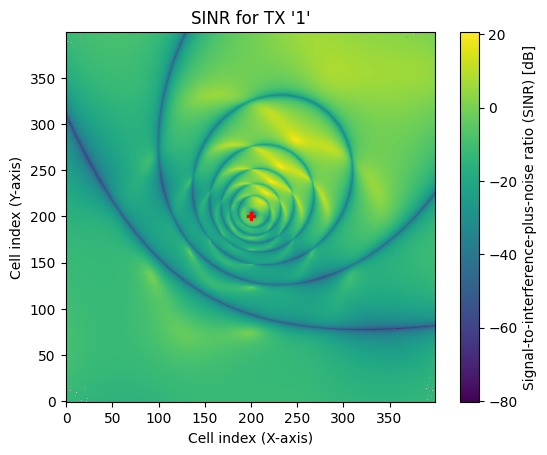

In [20]:
rm.show(metric="sinr", tx=1);

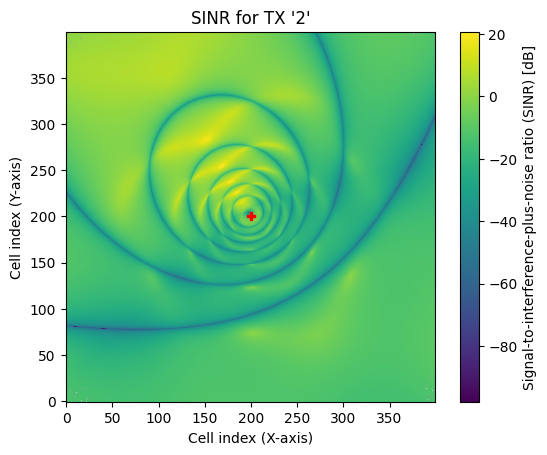

In [21]:
rm.show(metric="sinr", tx=2);

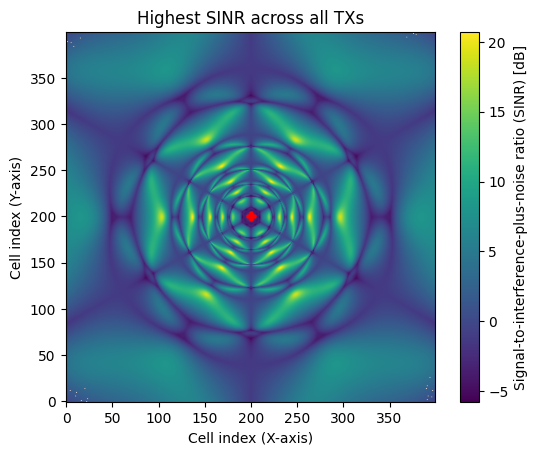

In [22]:
rm.show(metric="sinr");

# 3) Visualize the same with 1x16 BS with 6 sectors

In [23]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=1,
                    num_cols=16,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=6,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

Antenna Array Configuration Set:
  - Array: 1x16 (32 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [7.65]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 60.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_4 at position [[0, 0, 30]], azimuth 180.0°
Added BS_0_sector_5 at position [[0, 0, 30]], azimuth 240.0°
Added BS_0_sector_6 at position [[0, 0, 30]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


In [24]:
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

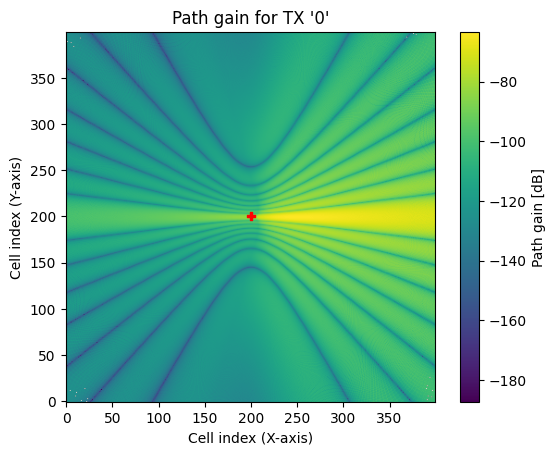

In [25]:
rm.show(metric="path_gain", tx=0);

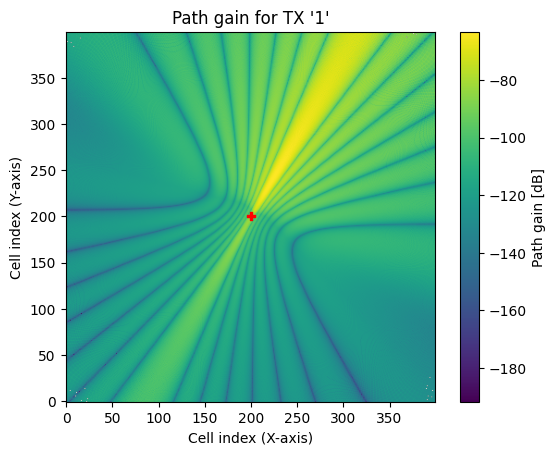

In [26]:
rm.show(metric="path_gain", tx=1);

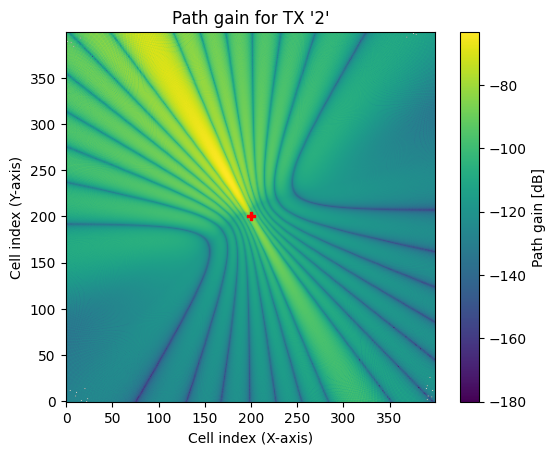

In [27]:
rm.show(metric="path_gain", tx=2);

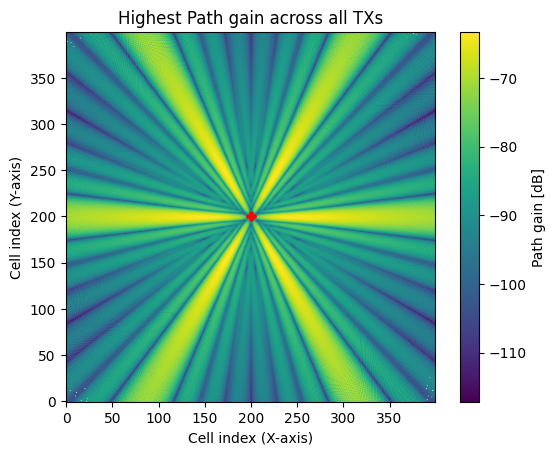

In [28]:
rm.show(metric="path_gain");

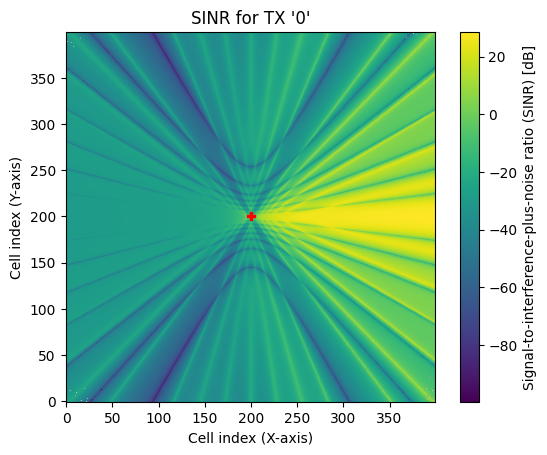

In [29]:
rm.show(metric="sinr", tx=0);

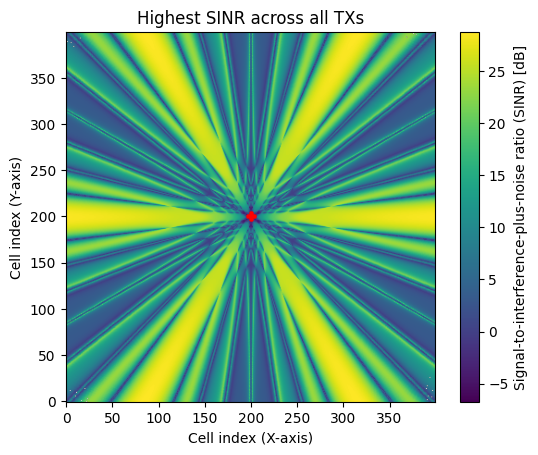

In [30]:
rm.show(metric="sinr");

# 4) Let's see the case with 3 sectors and 1x1 TX

In [31]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=1,
                    num_cols=1,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=3,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

Antenna Array Configuration Set:
  - Array: 1x1 (2 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [122.4]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 240.0°

Base Station 'BS_0' Summary:
  - Sectors: 3
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


In [32]:
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

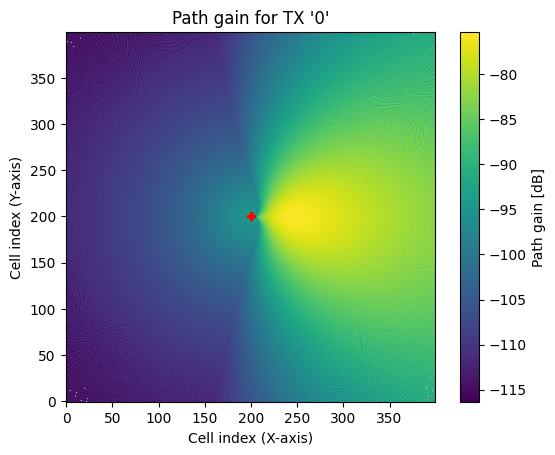

In [33]:
rm.show(metric="path_gain", tx=0);

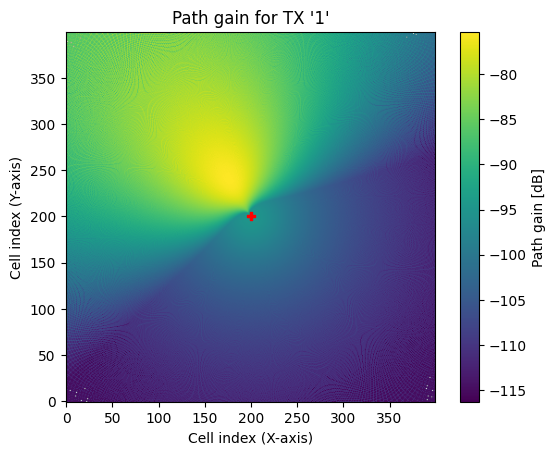

In [34]:
rm.show(metric="path_gain", tx=1);

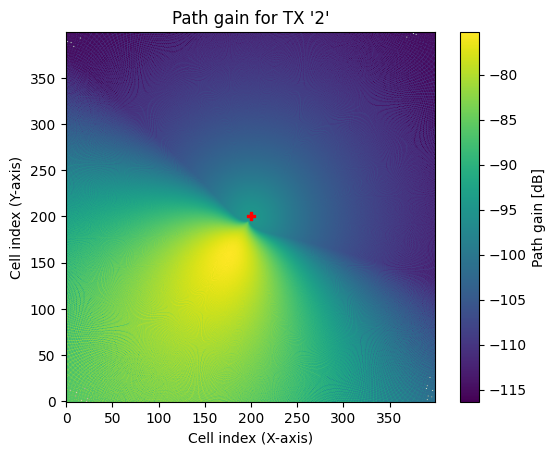

In [35]:
rm.show(metric="path_gain", tx=2);

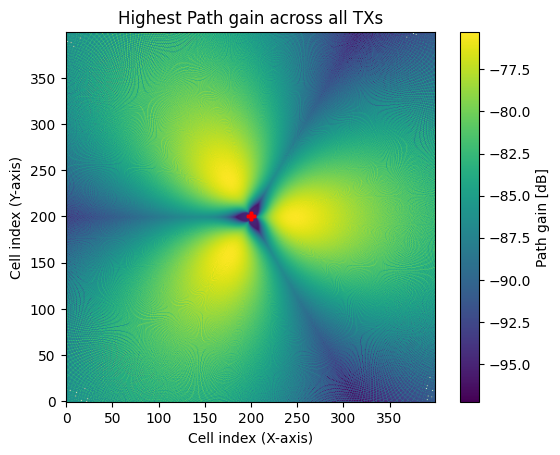

In [36]:
rm.show(metric="path_gain");

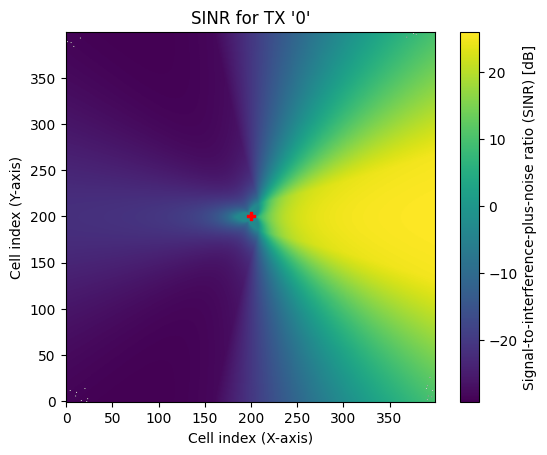

In [37]:
rm.show(metric="sinr", tx=0);

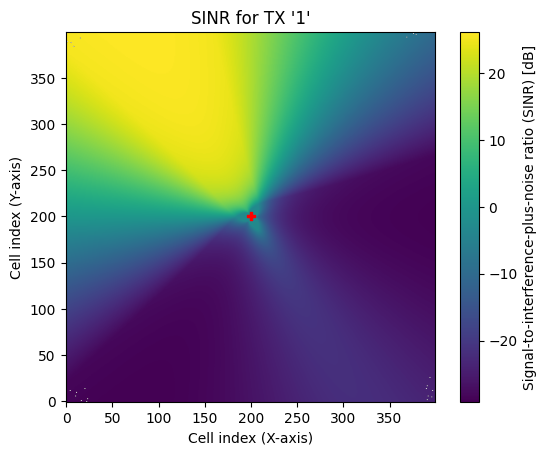

In [38]:
rm.show(metric="sinr", tx=1);

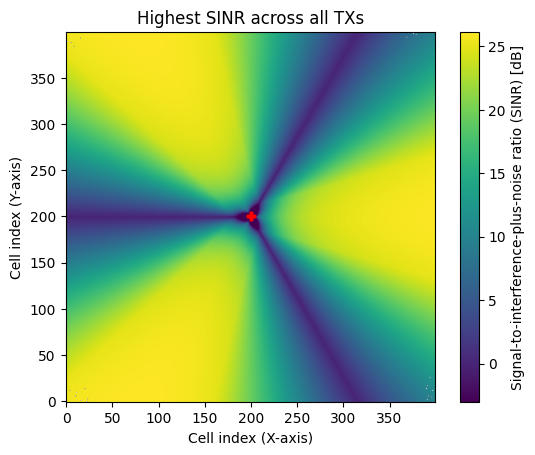

In [39]:
rm.show(metric="sinr");

# 5) 2x2 TX BS with 3 sectors

In [40]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=3,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [61.2]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 240.0°

Base Station 'BS_0' Summary:
  - Sectors: 3
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


In [41]:
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

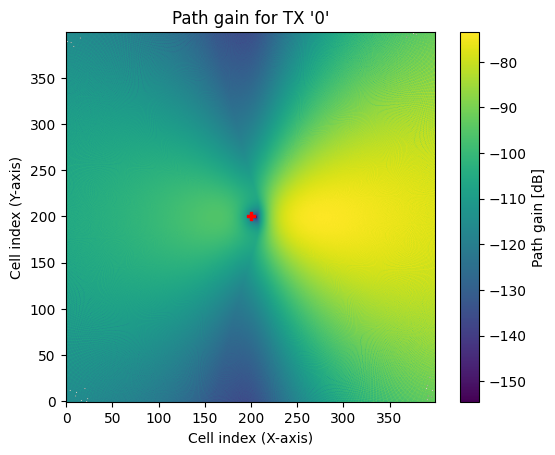

In [42]:
rm.show(metric="path_gain", tx=0);

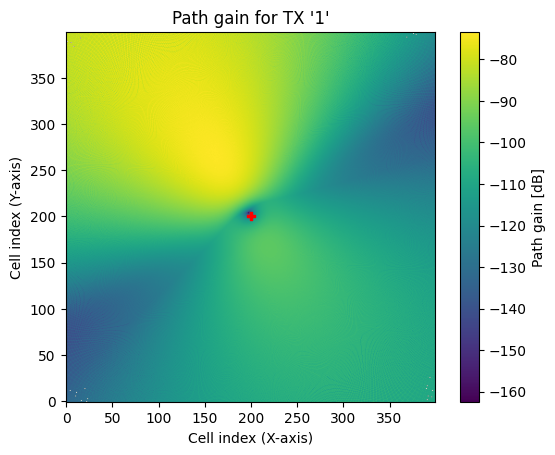

In [43]:
rm.show(metric="path_gain", tx=1);

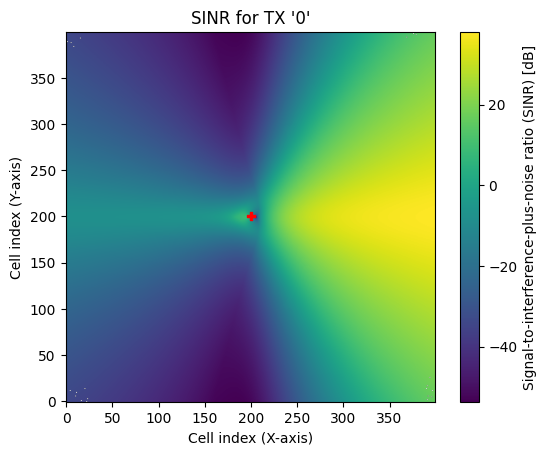

In [44]:
rm.show(metric="sinr", tx=0);

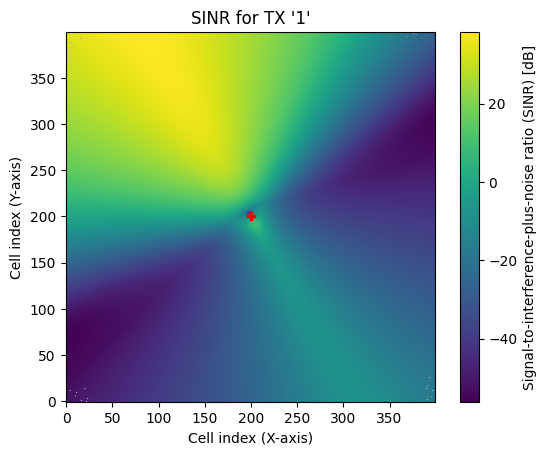

In [45]:
rm.show(metric="sinr", tx=1);

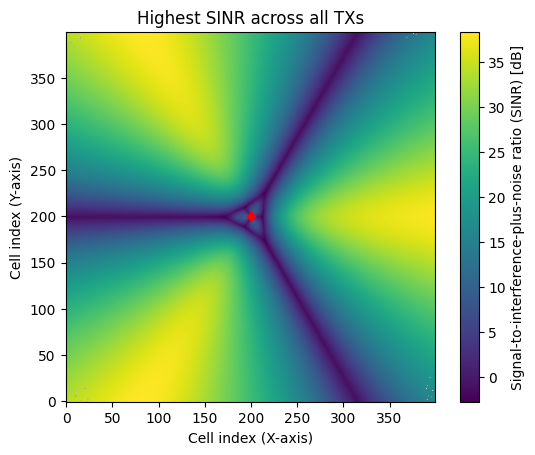

In [46]:
rm.show(metric="sinr");

# 6) 4x4 TX case with 3 sectors

In [47]:
scene = load_scene()

set_tx_antenna_array(scene,
                    num_rows=4,
                    num_cols=4,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="tr38901",
                    polarization="cross")

set_rx_antenna_array(scene,
                    num_rows=2,
                    num_cols=2,
                    vertical_spacing=0.5,
                    horizontal_spacing=0.5,
                    pattern="hw_dipole",
                    polarization="VH")

add_base_station(scene,
                "BS_0",
                position=[0, 0, BS_HEIGHT_OFFSET],
                num_sectors=3,
                mechanical_tilt=10,
                azimuth_offset=0.0,
                tx_power_dbm=43.0,
                display_radius=20.0)

Antenna Array Configuration Set:
  - Array: 4x4 (32 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [30.6]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Added BS_0_sector_1 at position [[0, 0, 30]], azimuth 0.0°
Added BS_0_sector_2 at position [[0, 0, 30]], azimuth 120.0°
Added BS_0_sector_3 at position [[0, 0, 30]], azimuth 240.0°

Base Station 'BS_0' Summary:
  - Sectors: 3
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[0], [0], [30]] m


In [112]:
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[400, 400],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

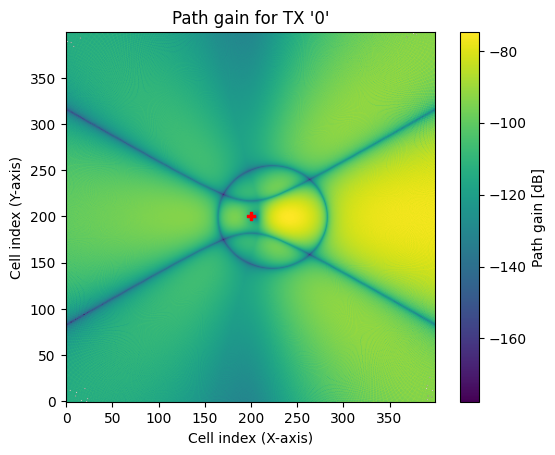

In [113]:
rm.show(metric="path_gain", tx=0);

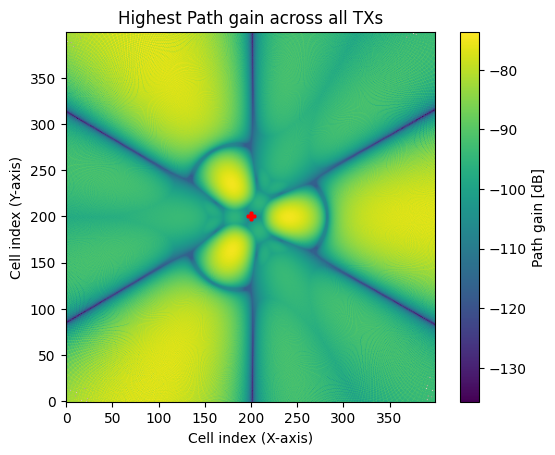

In [114]:
rm.show(metric="path_gain");

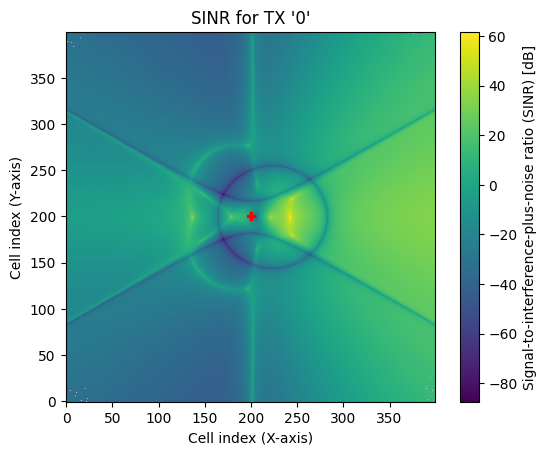

In [115]:
rm.show(metric="sinr", tx=0);

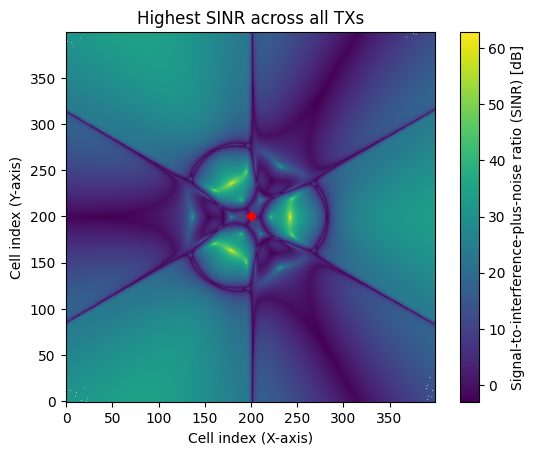

In [116]:
rm.show(metric="sinr");